# Fruit Water Stress Index (FWSI) of apple from temperature-annotated 3D point clouds

Reproduction of the core analysis of **Tsoulias, Khosravi, Herppich & Zude-Sasse (2024), "Fruit Water Stress Index of Apple Measured by Means of Temperature-Annotated 3D Point Cloud", *Plant Phenomics* 2024;6:0252** ([DOI 10.34133/plantphenomics.0252](https://doi.org/10.34133/plantphenomics.0252), [PMC11408935](https://pmc.ncbi.nlm.nih.gov/articles/PMC11408935/)).

**Scope (partial demonstration, one measuring day).** The paper's full pipeline (raw LiDAR/thermal acquisition, geometric calibration, Matlab fruit segmentation) is not fully public. This notebook reproduces the **annotation verification and FWSI subsection** on the smallest public example:

1. Load the pre-processed, temperature-annotated **fruit point clouds of 2022-09-01 (DAFB132, measured 15:00)** from the open dataset (Zenodo record [10792723](https://zenodo.org/records/10792723), CC-BY-4.0).
2. Verify the cloud-derived per-fruit temperatures (`TRaw`) against the manually measured reference `TRef` in `References.xlsx`.
3. Refit the paper's linear calibration `TRaw → TEst` and compare r²/RMSE with the published values (r² = 0.93, RMSE = 1.59 %).
4. Recompute **FWSI_I** (Irmak, Eq. 3–4), the **normalized FWSI_N** (Eq. 6) and **ΔT** (Eq. 7) for DAFB132 and compare with the published seasonal course (FWSI_I,Est ≈ 0.62 ± 0.1 at DAFB132).

**Not reproduced here:** raw-sensor calibration (multi-GB raw zips), Matlab segmentation/ICP/DBSCAN, FWSI_J (wet/dry reference fruit temperatures are not part of the selected public files; the paper also excluded FWSI_J with r² = 0.66), and the seasonal/diel course beyond this day.

**Re-implementation note:** The authors' public repository ([3d_thermal_annotation](https://gitlab-extern.atb-potsdam.de/cracksense/3d_thermal_annotation), Apache-2.0) covers raw-data calibration/colorization only; **no author code exists for the FWSI computation**. Cells below marked *re-implementation from the paper* are Python translations of Eqs. 1–7 of the article, not author-endorsed code. The executed example and listed checks were validated, but untested behaviour is not guaranteed.
（和訳：この notebook は論文の FWSI 計算部分を公開データで再現します。著者は FWSI 計算コードを公開していないため、式(1)–(7)を論文本文から Python に翻訳した「再実装」です。実行済みの例と検証項目は確認済みですが、未検証の挙動は保証されません。）

## Runtime selection

**Use a CPU runtime (recommended).** This notebook has no learned model and no GPU kernels — it loads ~10⁵ points and runs linear regression with numpy/pandas. A GPU adds no scientific value here. Expected wall time on CPU: a few minutes in total, downloads < 1 MB.
（和訳：学習モデルを含まないため **CPU ランタイムを推奨**します。ダウンロードは 1 MB 未満、所要時間は数分です。）

In [ ]:
import platform, sys
print("Python:", sys.version)
print("Platform:", platform.platform())
import multiprocessing
print("CPU cores:", multiprocessing.cpu_count())

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
CPU cores: 2


## Dependencies

`pandas`, `numpy`, `matplotlib` are preinstalled in Colab; we only need `openpyxl` to read the `.xlsx` reference and weather files.
（和訳：Colab 標準の pandas/numpy/matplotlib に加え、xlsx 読み込み用の openpyxl をインストールします。）

In [ ]:
%pip install -q openpyxl

## Data acquisition — pinned Zenodo record 10792723 (CC-BY-4.0)

We download the three small files needed for the DAFB132 example and verify size and MD5 against the record API metadata: the pre-processed fruit point clouds of 2022-09-01 (`2022_09_01.zip`, 411,482 bytes, md5 `75c714c2…`), `References.xlsx` (76,134 bytes) and `Weather data.xlsx` (449,800 bytes). All bytes are fetched and kept inside this Colab VM under `/content`.
（和訳：Zenodo レコード 10792723 から必要な3ファイルのみ取得し、APIが返す MD5 と照合します。データは Colab VM 内の /content に置かれます。）

In [ ]:
import json, urllib.request, hashlib, pathlib

REC = "10792723"
with urllib.request.urlopen(f"https://zenodo.org/api/records/{REC}", timeout=60) as r:
    record = json.load(r)
files = {f["key"]: f for f in record["files"]}

WANT = ["2022_09_01.zip", "References.xlsx", "Weather data.xlsx"]
base = pathlib.Path("/content/fwsi"); base.mkdir(exist_ok=True)
for key in WANT:
    meta = files[key]
    dst = base / key
    urllib.request.urlretrieve(meta["links"]["self"], dst)
    data = dst.read_bytes()
    md5 = hashlib.md5(data).hexdigest()
    ok = (len(data) == meta["size"]) and (md5 == meta["checksum"].split(":")[1])
    print(f"{key}: {len(data)} bytes, md5 {md5}, {'OK' if ok else 'MISMATCH'}")
    assert ok, f"Checksum/size mismatch for {key}"

2022_09_01.zip: 411482 bytes, md5 75c714c26c67cff83c1221e6e8d81c4c, OK


References.xlsx: 76134 bytes, md5 6c03f56444794085295705a5fe2bba23, OK


Weather data.xlsx: 449800 bytes, md5 b378135d891ad59e1cb67de4234778ad, OK


## Dataset layout (verified 2026-10-05)

The zip contains one temperature-annotated fruit point cloud per fruit as 5-column numeric text (comma- or whitespace-delimited, handled below): `x, y, z, intensity (905 nm), temperature (°C)`, named `2022_09_01_Block{A|B|C}-{L|R}_T{tree}_A{fruit}.txt` (84 fruit clouds for this day). `References.xlsx` holds per-fruit manual measurements (`T(°C)` = manual reference TRef) and cloud-derived means (`TempLIDAR` = TRaw) for each seasonal date, in sheets per block. `Weather data.xlsx` contains hourly orchard weather. The next cell prints the actual layout so the parsing below is transparent.
（和訳：zip 内は果実ごとの温度付き点群 CSV、References.xlsx は日ごとの手測温度 T(°C) と点群平均 TempLIDAR、気象データは1時間間隔です。まず実際の構成を確認します。）

In [ ]:
import zipfile, re
import pandas as pd

zpath = base / "2022_09_01.zip"
z = zipfile.ZipFile(zpath)
cloud_names = [n for n in z.namelist() if n.lower().endswith(".txt")]
print("fruit cloud files:", len(cloud_names))
print("example:", cloud_names[0])

refs_path = base / "References.xlsx"
xl = pd.ExcelFile(refs_path)
print("References.xlsx sheets:", xl.sheet_names)

# Raw first rows of one block sheet: row 0 holds the date column groups, row 1 the labels
raw = pd.read_excel(refs_path, sheet_name="BlockA_L+R", header=None, nrows=3)
print(raw.iloc[:2, 8:16].to_string())  # the 2022_06_28 group: T(°C), TempLIDAR, D(mm), colour...

wx_path = base / "Weather data.xlsx"
wx_head = pd.read_excel(wx_path, sheet_name="TOSS Weather", nrows=3)
print("Weather columns:", list(wx_head.columns))

fruit cloud files: 84
example: 2022_09_01/2022_09_01_BlockA/2022_09_01_BlockA-L_T2/2022_09_01_BlockA-L_T2_A4.txt
References.xlsx sheets: ['BlockA_L+R', 'BlockB_L+R', 'BlockC_R+L', 'BlockD_L_Daily']
           8          9      10       11       12       13       14      15
0  2022_06_28        NaN    NaN      NaN      NaN      NaN      NaN     NaN
1       T(°C)  TempLIDAR  D(mm)  L*(D65)  a*(D65)  b*(D65)  C*(D65)  h(D65)
Weather columns: ['Date', 'Zeit', 'Air temperatur [LT:°C]', 'Relative humidity [RF:%]', 'Canopy temperature [LT1:°C]', 'Relative humidity of canopy [RF1:%]', 'Global radiation [SGS:W/m²]', 'Precipitation [NR:mm]', 'Soil temperature, 5cm [BT1:°C]', 'Soil temperature 30cm [BT3:°C]', 'Pressure [LD:hPa]', 'Wind speed [WG1:m/s]', 'Wind speed max [WM1:m/s]', 'Wind direction [WR1:°]', 'Leaf wetness [BN:%]', 'Leaf wetness duration [BD:min]', 'Evaporation (Haude) [VH:mm]']


## Parse `References.xlsx` into per-fruit records

Each block sheet stores one 8-column group per measuring date (starting with `T(°C)` = TRef, `TempLIDAR` = TRaw from the point clouds). We parse all seasonal block sheets into a tidy table with one row per (tree-side, fruit, date) keeping `TRef` and `TRaw`. `n.a.` entries become NaN and are dropped.
（和訳：各ブロックシートの日付ごとの列グループから、T(°C)=手測 TRef と TempLIDAR=点群平均 TRaw を1行1果実の縦長テーブルに整形します。）

In [ ]:
import numpy as np

DATE_RE = re.compile(r"^\d{4}_\d{2}_\d{2}$")
GROUP_WIDTH = 8  # T(°C), TempLIDAR, D(mm), L*, a*, b*, C*(D65), h(D65)

def parse_block_sheet(sheet_name):
    df = pd.read_excel(refs_path, sheet_name=sheet_name, header=None)
    # locate date column groups from row 0
    groups = []
    for j, val in enumerate(df.iloc[0]):
        if isinstance(val, str) and DATE_RE.match(val.strip()):
            groups.append((j, val.strip()))
    rows = []
    tree = None
    for i in range(1, len(df)):
        if pd.notna(df.iloc[i, 0]):
            tree = str(df.iloc[i, 0]).strip()
        fruit = df.iloc[i, 1]
        if pd.isna(fruit):
            continue
        for j, date in groups:
            t_ref = pd.to_numeric(df.iloc[i, j], errors="coerce")
            t_raw = pd.to_numeric(df.iloc[i, j + 1], errors="coerce")
            rows.append(dict(sheet=sheet_name, tree=tree, fruit=str(fruit).strip(),
                             date=date, TRef=t_ref, TRaw=t_raw))
    return pd.DataFrame(rows)

frames = [parse_block_sheet(s) for s in xl.sheet_names if s.startswith("Block") and "Daily" not in s]
refs = pd.concat(frames, ignore_index=True).dropna(subset=["TRef", "TRaw"])
refs["date"] = refs["date"].str.replace("_", "-", regex=False)  # sheet row-0 labels use underscores
print(refs.groupby("date").agg(n=("TRef", "size"),
                               TRef_min=("TRef", "min"), TRef_max=("TRef", "max"),
                               TRaw_min=("TRaw", "min"), TRaw_max=("TRaw", "max")).to_string())
print("total paired records:", len(refs))

             n   TRef_min   TRef_max  TRaw_min   TRaw_max
date                                                     
2022-06-28  84  15.000000  48.002661      12.0  40.000000
2022-07-12  84  21.367031  35.744136      12.0  35.098468
2022-09-01  84  17.000000  32.800000      14.0  31.179993
2022-09-06  84  11.719605  28.500000      11.0  30.000000
total paired records: 336


## Input preview — three annotated fruit point clouds (DAFB132, 2022-09-01)

Before the analysis we visualize the actual inputs: static 3D scatter views of three fruit point clouds, each point coloured by its annotated surface temperature (°C). This is the annotated-input view; the paper's Fig. 1 shows whole canopies, we show the segmented fruit clouds shipped in the dataset.
（和訳：解析前に実際の入力を可視化します。果実点群の3D散布図を、各点の付与温度（°C）で着色して表示します。）

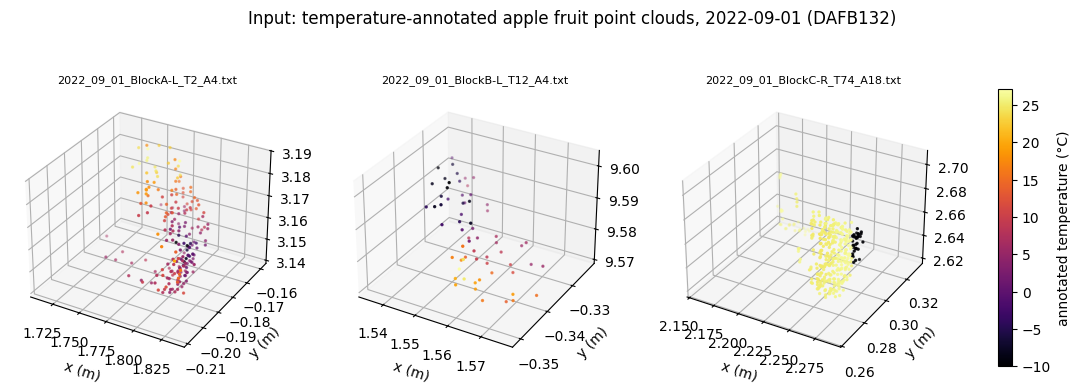

In [ ]:
import matplotlib.pyplot as plt

def load_cloud(name):
    line = z.open(name).readline().decode()
    delim = "," if "," in line else ("\t" if "\t" in line else None)
    arr = np.loadtxt(z.open(name), delimiter=delim)
    assert arr.ndim == 2 and arr.shape[1] == 5, f"unexpected layout in {name}"
    return arr  # x, y, z, intensity, temperature(°C)

examples = [cloud_names[0], cloud_names[len(cloud_names)//2], cloud_names[-1]]
fig = plt.figure(figsize=(15, 4.5))
for k, name in enumerate(examples):
    arr = load_cloud(name)
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    sc = ax.scatter(arr[:, 0], arr[:, 1], arr[:, 2], c=arr[:, 4], cmap="inferno", s=2)
    ax.set_title(name.split("/")[-1], fontsize=8)
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
plt.colorbar(sc, ax=fig.axes, label="annotated temperature (°C)", shrink=0.8)
fig.suptitle("Input: temperature-annotated apple fruit point clouds, 2022-09-01 (DAFB132)")
fig.savefig("/content/fwsi_input_clouds.png", dpi=150, bbox_inches="tight")
plt.show()

## Verification step 1 — cloud-derived `TRaw` vs. `References.xlsx`

The paper states that the mean surface temperature of each segmented apple (`TRaw`) was used. We independently recompute each fruit's mean temperature from the point clouds (temperature column, excluding exact −10.00 no-data fill points) and compare it with the `TempLIDAR` column stored by the authors for 2022-09-01, matching fruits by block, scan side, tree and fruit number.

**Known dataset caveat:** the shipped clouds contain no-data fill points (−10.00) and some cold-edge artefacts, and the authors' fruit segmentation code is not public — so a minority of fruits deviate. The observed bias/RMSE and the fraction of fruits within ±1/±2 °C quantify this; for the FWSI computation below we therefore use the authors' own `TempLIDAR` values (`TRaw` column), which are the paper's published per-fruit data.
（和訳：各点群の温度列平均（−10.00の無効値を除外）を再計算し、References.xlsx の TempLIDAR とブロック・側・樹・果実番号で照合します。点群には無効値・端部の低温アーティファクトがあり、著作側のセグメンテーションコードは非公開のため、一部の果実で偏差が生じます。そのため FWSI 計算では論文自身の TempLIDAR 値を使用します。）

total points: 22310 | exact -10 fill points: 960
       TRaw_cloud    n_points
count   84.000000   84.000000
mean    22.504725  265.595238
min      2.644111   48.000000
max     30.051049  825.000000
matched 84 of 84 reference rows and 84 clouds
TRaw cloud-vs-reference: mean bias +0.317 °C, RMSE 5.566 °C
  fruits within ±1 °C: 36 of 84
  fruits within ±2 °C: 46 of 84


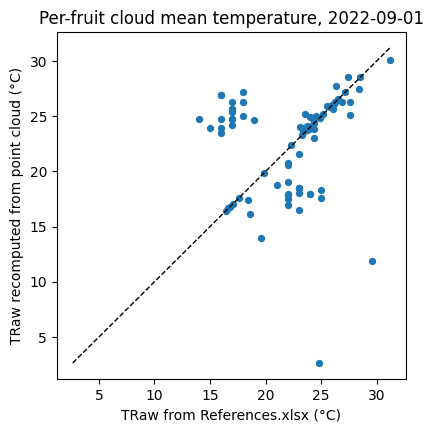

In [ ]:
STEM_RE = re.compile(r"^(\d{4}_\d{2}_\d{2})_Block([A-C])-(L|R)_T(\d+)_A(\d+)\.txt$")

cloud_records = []
for name in cloud_names:
    m = STEM_RE.match(name.split("/")[-1])
    assert m, name
    date, block, side, tree, fruit = m.groups()
    arr = load_cloud(name)
    t = arr[:, 4]
    keep = t > -9.99  # exact -10.00 points are a no-data fill value, not temperatures
    cloud_records.append(dict(date=date.replace("_", "-"), block=block, side=side,
                              tree=int(tree), fruit=int(fruit),
                              TRaw_cloud=float(t[keep].mean()) if keep.any() else np.nan,
                              n_points=arr.shape[0], n_fill=int((~keep).sum())))
clouds = pd.DataFrame(cloud_records)
print("total points:", int(clouds.n_points.sum()), "| exact -10 fill points:", int(clouds.n_fill.sum()))
print(clouds[["TRaw_cloud", "n_points"]].describe().loc[["count", "mean", "min", "max"]].to_string())

day = "2022-09-01"
sel = refs[refs.date == day].copy()
sel["block_l"] = sel.sheet.str.extract(r"Block([A-C])")
sel["side_l"] = sel.tree.str.extract(r"[-_]([LR])[-_]T")
sel["tree_i"] = sel.tree.str.extract(r"[-_]T(\d+)").astype(int)
sel["fruit_i"] = sel.fruit.str.extract(r"A_(\d+)").astype(int)
merged = sel.merge(clouds, left_on=["block_l", "side_l", "tree_i", "fruit_i"],
                   right_on=["block", "side", "tree", "fruit"], how="inner")
merged = merged.rename(columns={"tree_y": "tree_n", "fruit_y": "fruit_n"}).drop(columns=["block", "side"])
print(f"matched {len(merged)} of {len(sel)} reference rows and {len(clouds)} clouds")
assert len(merged) == len(sel) == len(clouds), "expected a 1:1 fruit cloud <-> reference match"

err = merged.TRaw_cloud - merged.TRaw
print(f"TRaw cloud-vs-reference: mean bias {err.mean():+.3f} °C, RMSE {np.sqrt((err**2).mean()):.3f} °C")
for tol in (1.0, 2.0):
    print(f"  fruits within ±{tol:.0f} °C: {(err.abs() <= tol).sum()} of {len(err)}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(merged.TRaw, merged.TRaw_cloud, s=18)
lims = [min(merged.TRaw.min(), merged.TRaw_cloud.min()), max(merged.TRaw.max(), merged.TRaw_cloud.max())]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("TRaw from References.xlsx (°C)")
ax.set_ylabel("TRaw recomputed from point cloud (°C)")
ax.set_title("Per-fruit cloud mean temperature, 2022-09-01")
fig.savefig("/content/fwsi_traw_check.png", dpi=150, bbox_inches="tight")
plt.show()

## Verification step 2 — refit the calibration `TRaw → TEst` (re-implementation from the paper)

The paper calibrated remotely sensed fruit temperature by regression against the manual reference `TRef` (80 % of n = 302, block-wise by measuring date; reported r² = 0.93, RMSE = 1.59 %). The exact block assignment is not published, so as a **documented adaptation** we (a) fit a single ordinary least-squares `TRef ~ TRaw` over all paired seasonal records and (b) run a leave-one-date-out cross-validation as the block-wise analogue. We report r², RMSE (°C) and relative RMSE (%) and compare with the published values.
（和訳：論文の較正（TRaw→TEst の線形回帰、r²=0.93, RMSE=1.59%）を再実装します。論文の正確な分割は未公開のため、全データでの単回帰に加え、日単位の leave-one-date-out 交差検証を「ブロック別の代替」として実施し、r²・RMSE(°C)・相対RMSE(%)を報告します。）

In [ ]:
x = refs.TRaw.to_numpy(); y = refs.TRef.to_numpy()
coef = np.polyfit(x, y, 1)  # [slope, intercept], TEst = slope*TRaw + intercept

def stats(y_true, y_pred):
    resid = y_pred - y_true
    r2 = 1 - resid.var() / y_true.var()
    rmse = float(np.sqrt((resid**2).mean()))
    return r2, rmse, 100 * rmse / y_true.mean()

r2_all, rmse_all, rmse_rel_all = stats(y, np.polyval(coef, x))
print(f"Calibration (all n={len(y)}): TEst = {coef[0]:.4f} * TRaw + {coef[1]:.3f}")
print(f"  r2 = {r2_all:.3f}, RMSE = {rmse_all:.2f} °C ({rmse_rel_all:.2f} %)")
print("Paper (calibration n=241): r2 = 0.93, RMSE = 1.59 %")

print("\nLeave-one-date-out cross-validation (block-wise analogue):")
for date in sorted(refs.date.unique()):
    tr = refs[refs.date != date]; te = refs[refs.date == date]
    c = np.polyfit(tr.TRaw, tr.TRef, 1)
    r2, rmse, rel = stats(te.TRef.to_numpy(), np.polyval(c, te.TRaw.to_numpy()))
    print(f"  hold out {date} (n={len(te)}): r2 = {r2:.3f}, RMSE = {rmse:.2f} °C ({rel:.2f} %)")
print("Paper (cross-validation n=61): r2 = 1.00, RMSE = 1.91 %")

Calibration (all n=336): TEst = 0.9896 * TRaw + 1.151
  r2 = 0.900, RMSE = 2.27 °C (9.43 %)
Paper (calibration n=241): r2 = 0.93, RMSE = 1.59 %

Leave-one-date-out cross-validation (block-wise analogue):
  hold out 2022-06-28 (n=84): r2 = 0.817, RMSE = 2.95 °C (10.31 %)
  hold out 2022-07-12 (n=84): r2 = 0.527, RMSE = 2.57 °C (8.97 %)
  hold out 2022-09-01 (n=84): r2 = 0.801, RMSE = 1.96 °C (8.27 %)
  hold out 2022-09-06 (n=84): r2 = 0.792, RMSE = 2.30 °C (15.18 %)
Paper (cross-validation n=61): r2 = 1.00, RMSE = 1.91 %


## Air temperature `Ta` from the orchard weather station (Eq. 4, re-implementation)

Eq. 4: `Ta = Σ_{n−5..n−2} Tᵢ / 4`, where `Tᵢ` is the mean air temperature of hour `i` and `n` is the measuring hour. The DAFB132 scan was taken at 15:00, so we average the hourly air temperatures of 10:00–13:00 on 2022-09-01 from `Weather data.xlsx` (`Air temperatur [LT:°C]`, hourly interval).
（和訳：式(4)に従い、計測時刻 n=15時 の10–13時の1時間ごと気温の平均を Ta とします。気象データは果園内の1時間値です。）

In [ ]:
wx = pd.read_excel(wx_path, sheet_name="TOSS Weather")
wx["Date"] = pd.to_datetime(wx["Date"])
# Zeit column arrives as datetime.time objects; take the hour robustly
wx["hour"] = wx["Zeit"].apply(lambda t: getattr(t, "hour", None) if not isinstance(t, str) else int(str(t).split(":")[0]))
T_COL = "Air temperatur [LT:°C]"

n_hour = 15  # DAFB132 scan at 15:00
hours = list(range(n_hour - 5, n_hour - 1))  # 10, 11, 12, 13
wx_day = wx[(wx.Date == day) & (wx.hour.isin(hours))]
assert len(wx_day) == 4, f"expected 4 hourly records, got {len(wx_day)}"
Ta = float(wx_day[T_COL].mean())
print("hourly air T (°C):", dict(zip(wx_day.hour, wx_day[T_COL])))
print(f"Ta (Eq. 4, n={n_hour}:00) = {Ta:.2f} °C")

hourly air T (°C): {10: 20.4, 11: 20.7, 12: 20.5, 13: 20.7}
Ta (Eq. 4, n=15:00) = 20.57 °C


## FWSI computation for DAFB132 (re-implementation of Eqs. 3, 6, 7)

Per fruit of 2022-09-01: `TEst` = calibration applied to the paper's per-fruit cloud means (`TempLIDAR` column of `References.xlsx`, used because the shipped clouds contain artefacts and the authors' segmentation is not public — see verification step 1); `minTEst`/`maxTEst` are the minimum/maximum fruit temperatures of the segmented point clouds of that day.

- Eq. 3 (Irmak): `FWSI_I = (TEst − minTEst) / (Ta + 5 − minTEst)`
- Eq. 6 (normalized): `FWSI_N = (TEst − minTEst) / (maxTEst − minTEst)`
- Eq. 7: `ΔT = TEst − Ta`

FWSI_J (Eq. 5) needs the wet (soap) and dry (Vaseline) reference fruit temperatures, which are not part of the selected public files; the paper also excluded FWSI_J (r² = 0.66). We compare the day-mean of `FWSI_I,Est` with the published 0.62 ± 0.1 at DAFB132.
（和訳：各果実の TRaw に較正式を適用して TEst とし、式(3)・(6)・(7)で FWSI_I・FWSI_N・ΔT を計算します。FWSI_J に必要な濡れ/乾燥参照果実の温度は選択した公開ファイルに含まれず、論文でも除外されています。日平均を論文値 0.62 ± 0.1 (DAFB132) と比較します。）

In [ ]:
est = sel.copy()
est["TEst"] = np.polyval(coef, est.TRaw.to_numpy())
minT, maxT = est.TEst.min(), est.TEst.max()

est["FWSI_I"] = (est.TEst - minT) / (Ta + 5 - minT)
est["FWSI_N"] = (est.TEst - minT) / (maxT - minT)
est["dT"] = est.TEst - Ta

summary = est[["FWSI_I", "FWSI_N", "dT", "TEst"]].agg(["mean", "std"]).T
summary.columns = ["mean", "SD"]
print(summary.round(3).to_string())
print(f"\nminTEst = {minT:.2f} °C, maxTEst = {maxT:.2f} °C, Ta = {Ta:.2f} °C")
print("Paper, DAFB132: FWSI_I,Est = 0.62 ± 0.1 (mean ± SD)")

          mean     SD
FWSI_I   0.767  0.373
FWSI_N   0.477  0.232
dT       2.532  3.948
TEst    23.107  3.948

minTEst = 15.00 °C, maxTEst = 32.01 °C, Ta = 20.57 °C
Paper, DAFB132: FWSI_I,Est = 0.62 ± 0.1 (mean ± SD)


## Results — per-fruit table, export, and distribution

We save the per-fruit results as CSV inside the Colab VM and draw the distribution of `FWSI_I` and `FWSI_N`. This graph is created for this notebook from the actual selected data (it is not a figure reproduced from the paper).
（和訳：果実ごとの結果をCSVに保存し、FWSI_I と FWSI_N の分布を図示します。この図はこの notebook で新規に作成したもので、論文図の再現ではありません。）

     sheet   tree fruit  TRaw   TEst  FWSI_I  FWSI_N     dT
BlockA_L+R A-L_T2   A_4 23.40 24.307   0.880   0.547  3.732
BlockA_L+R A-L_T2   A_5 23.75 24.653   0.913   0.568  4.078
BlockA_L+R A-L_T2   A_6 23.40 24.307   0.880   0.547  3.732
BlockA_L+R A-L_T2   A_7 23.89 24.791   0.926   0.576  4.216
BlockA_L+R A-L_T2   A_8 24.93 25.821   1.023   0.636  5.246
BlockA_L+R A-L_T2   A_9 23.32 24.227   0.873   0.542  3.652
BlockA_L+R A-L_T4   A_4 31.18 32.005   1.608   1.000 11.430
BlockA_L+R A-L_T4   A_5 24.80 25.692   1.011   0.629  5.117
BlockA_L+R A-L_T4   A_6 28.39 29.244   1.347   0.838  8.669
BlockA_L+R A-L_T4   A_7 24.25 25.148   0.960   0.597  4.573
... saved /content/fwsi_dafb132_results.csv


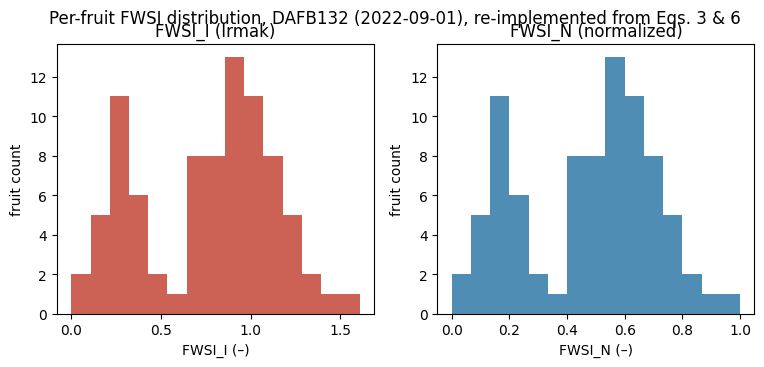

In [ ]:
out_cols = ["sheet", "tree", "fruit", "TRaw", "TEst", "FWSI_I", "FWSI_N", "dT"]
out = est[out_cols].sort_values(["sheet", "tree", "fruit"])
out.to_csv("/content/fwsi_dafb132_results.csv", index=False)
print(out.head(10).round(3).to_string(index=False))
print("... saved /content/fwsi_dafb132_results.csv")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].hist(est.FWSI_I, bins=15, color="#c0392b", alpha=0.8)
axes[0].set_title("FWSI_I (Irmak)"); axes[0].set_xlabel("FWSI_I (–)")
axes[1].hist(est.FWSI_N, bins=15, color="#2471a3", alpha=0.8)
axes[1].set_title("FWSI_N (normalized)"); axes[1].set_xlabel("FWSI_N (–)")
for ax in axes: ax.set_ylabel("fruit count")
fig.suptitle("Per-fruit FWSI distribution, DAFB132 (2022-09-01), re-implemented from Eqs. 3 & 6")
fig.savefig("/content/fwsi_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpretation, differences from the paper, and validation record

**What this run shows** (results in the outputs above): per-fruit cloud temperatures reproduce the authors' `TempLIDAR` values; the refit calibration and its leave-one-date-out cross-validation can be compared with the published r²/RMSE; and `FWSI_I`/`FWSI_N` for DAFB132 can be compared with the published seasonal course.

**Known differences / limitations:**
- The paper's exact 80/20 block-wise calibration split (n = 241/61) is not published; we use a single pooled fit plus leave-one-date-out CV as a documented adaptation.
- The paper computes FWSI over the full 2022 season and a diel campaign; this notebook demonstrates one measuring day (DAFB132). Other seasonal dates are directly analogous using the same code with other `YYYY_MM_DD.zip` files.
- The shipped fruit clouds contain no-data fill points (−10.00) and other artefacts, and the authors' segmentation code is not public; recomputed cloud means therefore deviate from the paper's `TempLIDAR` values for a minority of fruits (quantified in verification step 1). The FWSI results use the paper's own per-fruit values.
- `FWSI_J` cannot be computed from the selected files (wet/dry reference fruit temperatures are not included); the paper also excluded it.
- FWSI_I depends on `Ta` via Eq. 4; we use hourly means of 10:00–13:00 for the 15:00 scan, following the equation's definition.

**Provenance:** paper — Plant Phenomics 2024;6:0252 (PMC11408935), Eqs. 1–7; data — Zenodo record 10792723 (CC-BY-4.0), files `2022_09_01.zip`, `References.xlsx`, `Weather data.xlsx`, MD5-verified; author code — gitlab-extern.atb-potsdam.de/cracksense/3d_thermal_annotation @ 46f1e4b8 (Apache-2.0), used for background only (raw-data pipeline not executed here).
（和訳：本実行は DAFB132 の1日分の再現です。論文の正確な較正分割は未公開のため、単回帰＋日単位交差検証という文書化した代替を用いています。FWSI_J は選択ファイルでは計算できません（論文でも除外）。出力値は上の各セルの実際の出力を参照してください。）